# 04c — Pre-training real del D10Sformer

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)  
**Fase:** 4c — Pre-training MLM puro sobre el corpus combinado (clubes + selecciones)

## Objetivo

1. **Entrenar 5 épocas** sobre los 11.852 docs del corpus combinado (`pretrain.pkl`).
2. Objective: **MLM puro** (BERT-style), 15% de tokens enmascarables.
3. Evaluar contra el corpus val (`val.pkl`, 1.232 docs de selecciones 2023-2024).
4. Persistir **`best.pt`** (mejor por val_loss) para usar en Fase 4d (fine-tuning).
5. Comparar las curvas finales contra el smoke test de Fase 4b.

## Pre-requisito CRÍTICO

**Hardware accelerator: T4 (o L4) GPU**, no CPU.  
`Runtime → Change runtime type → GPU`.  
Si corre en CPU, el run de 925 pasos tarda ~10 horas en vez de ~15 minutos.

---
## 1. Setup + chequeo de GPU

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [2]:
import torch
print(f'torch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if not torch.cuda.is_available():
    raise RuntimeError(
        '❌ NO HAY GPU. Cambiá el runtime: Runtime → Change runtime type → T4 GPU.\n'
        'El pre-training tarda 10h en CPU vs 15min en T4. Abortando.'
    )
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print('✓ GPU OK — listo para entrenar')

torch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
Memoria GPU: 14.6 GB
✓ GPU OK — listo para entrenar


In [3]:
import sys
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

ROOT = Path(PROJECT_ROOT)
sys.path.insert(0, str(ROOT / 'src'))

DATA_PROCESSED = ROOT / 'data' / 'processed'
CORPUS_DIR = DATA_PROCESSED / 'corpus'
VOCAB_PATH = DATA_PROCESSED / 'vocab.json'
CKPT_DIR = ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

from data.vocabulary import FootballVocab
from data.tokenizer import MatchTokenizer
from data.dataset import MatchDataset
from data.collator import MLMCollator
from models.d10sformer import D10Sformer, D10SformerConfig
from training.trainer import Trainer, TrainerConfig, LossSpec

---
## 2. Cargar corpus + tokenizer + collator

In [4]:
vocab = FootballVocab.load(VOCAB_PATH)
tokenizer = MatchTokenizer(vocab, max_seq_length=80)

with open(CORPUS_DIR / 'pretrain.pkl', 'rb') as f:
    pretrain_docs = pickle.load(f)
with open(CORPUS_DIR / 'val.pkl', 'rb') as f:
    val_docs = pickle.load(f)

print(f'Corpus pretrain: {len(pretrain_docs):,} docs')
print(f'Corpus val:      {len(val_docs):,} docs')

ds_train = MatchDataset(pretrain_docs, tokenizer)
ds_val   = MatchDataset(val_docs, tokenizer)

collator = MLMCollator(vocab, mlm_probability=0.15, seed=42)

BATCH_SIZE = 64
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collator, num_workers=0)
val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collator, num_workers=0)

steps_per_epoch = len(train_loader)
print(f'\nTrain batches/época: {steps_per_epoch}')
print(f'Val batches: {len(val_loader)}')

Corpus pretrain: 11,852 docs
Corpus val:      1,232 docs

Train batches/época: 186
Val batches: 20


---
## 3. Configurar Trainer (5 épocas)

In [5]:
EPOCHS = 5
MAX_STEPS = steps_per_epoch * EPOCHS
print(f'EPOCHS = {EPOCHS}')
print(f'Pasos totales = {MAX_STEPS} ({steps_per_epoch} × {EPOCHS})')

model_config = D10SformerConfig(
    vocab_size=len(vocab),
    d_model=256, num_layers=6, num_heads=8, d_ff=1024,
    max_seq_length=80, num_segments=8,
    dropout=0.1, attention_dropout=0.1,
    pad_token_id=vocab.encode('[PAD]'),
    tie_mlm_weights=True,
)
model = D10Sformer(model_config)
print(f'Modelo: {model.num_parameters():,} parámetros')

trainer_config = TrainerConfig(
    lr=5e-4, weight_decay=0.01, grad_clip_norm=1.0,
    warmup_ratio=0.1,
    max_steps=MAX_STEPS,
    mixed_precision=True,    # AMP en GPU
    log_every=25,
    eval_every=100,          # ~9 evals durante el run
    save_every=250,          # ~3 checkpoints intermedios (para resumir)
    save_best=True,          # ← este es el que vamos a usar en 4d
    output_dir=str(CKPT_DIR),
    run_name='pretrain_5ep',
    seed=42,
)
loss_spec = LossSpec(use_mlm=True)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=trainer_config,
    loss_spec=loss_spec,
)
print(f'Device: {trainer.device}')
print(f'AMP enabled: {trainer.use_amp}')
print(f'Output dir: {trainer.output_dir}')

EPOCHS = 5
Pasos totales = 930 (186 × 5)
Modelo: 6,131,920 parámetros
Device: cuda
AMP enabled: True
Output dir: /content/drive/MyDrive/d10sformer/checkpoints/pretrain_5ep


---
## 4. Pre-training (5 épocas)

In [6]:
import time
t0 = time.time()
trainer.train()
elapsed = time.time() - t0
print(f'\n✓ Pre-training completado en {elapsed/60:.1f} min ({MAX_STEPS/elapsed:.1f} step/s)')
print(f'  Best val_loss: {trainer.best_val_loss:.4f}')
print(f'  Best checkpoint: {trainer.output_dir / "best.pt"}')

[step     25/930] lr=1.34e-04  loss=8.2343  ppl=3768.06  mlm_acc=0.0406  (9.4 step/s)
[step     50/930] lr=2.69e-04  loss=7.4243  ppl=1676.21  mlm_acc=0.1321  (13.7 step/s)
[step     75/930] lr=4.03e-04  loss=6.6787  ppl=795.29  mlm_acc=0.1464  (16.2 step/s)
[step    100/930] lr=5.00e-04  loss=6.0087  ppl=406.95  mlm_acc=0.1545  (17.1 step/s)
[eval @ step    100] val_loss=3.2071  val_ppl=24.71  val_acc=0.2755
[step    125/930] lr=4.98e-04  loss=5.4124  ppl=224.16  mlm_acc=0.1692  (15.8 step/s)
[step    150/930] lr=4.94e-04  loss=5.2474  ppl=190.07  mlm_acc=0.1759  (16.6 step/s)
[step    175/930] lr=4.88e-04  loss=5.3248  ppl=205.36  mlm_acc=0.1662  (17.4 step/s)
[step    200/930] lr=4.80e-04  loss=5.1023  ppl=164.40  mlm_acc=0.1592  (18.1 step/s)
[eval @ step    200] val_loss=2.7334  val_ppl=15.39  val_acc=0.2764
[step    225/930] lr=4.70e-04  loss=4.9730  ppl=144.46  mlm_acc=0.1809  (17.8 step/s)
[step    250/930] lr=4.58e-04  loss=5.0763  ppl=160.18  mlm_acc=0.1658  (18.3 step/s)
[st

---
## 5. Curvas de loss / accuracy / lr

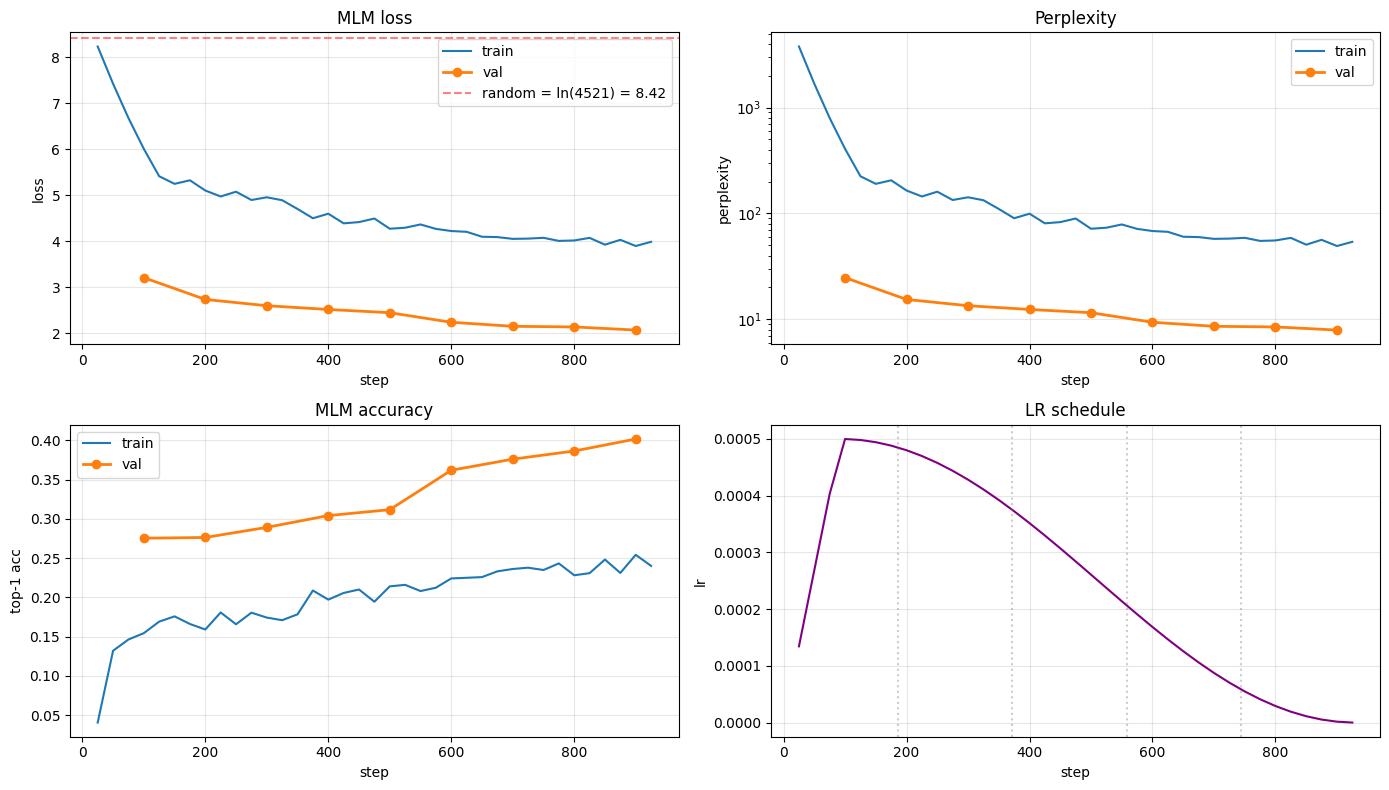

In [7]:
log_path = trainer.log_path
rows = [json.loads(line) for line in log_path.read_text().splitlines() if line.strip()]
train_rows = [r for r in rows if 'phase' not in r]
eval_rows  = [r for r in rows if r.get('phase') == 'eval']

steps_train = [r['step'] for r in train_rows]
loss_train  = [r['loss'] for r in train_rows]
ppl_train   = [r['mlm_perplexity'] for r in train_rows]
acc_train   = [r['mlm_acc'] for r in train_rows]
lr_train    = [r['lr'] for r in train_rows]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(steps_train, loss_train, label='train')
if eval_rows:
    axes[0, 0].plot([r['step'] for r in eval_rows],
                    [r['val_loss'] for r in eval_rows], 'o-', label='val', linewidth=2)
axes[0, 0].axhline(np.log(len(vocab)), linestyle='--', color='red', alpha=0.5,
                   label=f'random = ln({len(vocab)}) = {np.log(len(vocab)):.2f}')
axes[0, 0].set_xlabel('step'); axes[0, 0].set_ylabel('loss'); axes[0, 0].set_title('MLM loss')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(steps_train, ppl_train, label='train')
if eval_rows:
    axes[0, 1].plot([r['step'] for r in eval_rows],
                    [r['val_mlm_perplexity'] for r in eval_rows], 'o-', label='val', linewidth=2)
axes[0, 1].set_xlabel('step'); axes[0, 1].set_ylabel('perplexity')
axes[0, 1].set_title('Perplexity'); axes[0, 1].set_yscale('log')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(steps_train, acc_train, label='train')
if eval_rows:
    axes[1, 0].plot([r['step'] for r in eval_rows],
                    [r['val_mlm_acc'] for r in eval_rows], 'o-', label='val', linewidth=2)
axes[1, 0].set_xlabel('step'); axes[1, 0].set_ylabel('top-1 acc'); axes[1, 0].set_title('MLM accuracy')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(steps_train, lr_train, color='purple')
for ep in range(1, EPOCHS):
    axes[1, 1].axvline(ep * steps_per_epoch, color='gray', linestyle=':', alpha=0.4)
axes[1, 1].set_xlabel('step'); axes[1, 1].set_ylabel('lr'); axes[1, 1].set_title('LR schedule')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(trainer.output_dir / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
# Diagnóstico cuantitativo y comparación con smoke
print('=== Diagnóstico de pre-training ===')
print(f'Random baseline (ln(V)):       {np.log(len(vocab)):.4f}')
print(f'Loss inicial    (paso {steps_train[0]:>4}): {loss_train[0]:.4f}  ppl {ppl_train[0]:8.2f}  acc {acc_train[0]:.4f}')
print(f'Loss final      (paso {steps_train[-1]:>4}): {loss_train[-1]:.4f}  ppl {ppl_train[-1]:8.2f}  acc {acc_train[-1]:.4f}')
print(f'Reducción de loss:              {100 * (loss_train[0] - loss_train[-1]) / loss_train[0]:.1f}%')

if eval_rows:
    val_losses = [r['val_loss'] for r in eval_rows]
    val_accs   = [r['val_mlm_acc'] for r in eval_rows]
    print(f'\nVal evolution:')
    print(f'  primer eval: loss={val_losses[0]:.4f}  acc={val_accs[0]:.4f}')
    print(f'  último eval: loss={val_losses[-1]:.4f}  acc={val_accs[-1]:.4f}')
    print(f'  mejor val_loss: {min(val_losses):.4f} (step {eval_rows[val_losses.index(min(val_losses))]["step"]})')
    print(f'  mejor val_acc:  {max(val_accs):.4f} (step {eval_rows[val_accs.index(max(val_accs))]["step"]})')

# Comparación con smoke (si existe)
smoke_log = CKPT_DIR / 'smoke_test_pretrain' / 'metrics.jsonl'
if smoke_log.exists():
    smoke_rows = [json.loads(l) for l in smoke_log.read_text().splitlines() if l.strip()]
    smoke_eval = [r for r in smoke_rows if r.get('phase') == 'eval']
    if smoke_eval:
        smoke_final_val_loss = smoke_eval[-1]['val_loss']
        smoke_final_val_acc  = smoke_eval[-1]['val_mlm_acc']
        print(f'\nComparación vs smoke (200 pasos, subset 1000 docs):')
        print(f'  smoke val_loss = {smoke_final_val_loss:.4f}')
        print(f'  4c    val_loss = {min(val_losses):.4f}  (mejora: {100*(smoke_final_val_loss - min(val_losses)) / smoke_final_val_loss:.1f}%)')
        print(f'  smoke val_acc  = {smoke_final_val_acc:.4f}')
        print(f'  4c    val_acc  = {max(val_accs):.4f}  (mejora: {100*(max(val_accs) - smoke_final_val_acc) / smoke_final_val_acc:.1f}%)')

=== Diagnóstico de pre-training ===
Random baseline (ln(V)):       8.4165
Loss inicial    (paso   25): 8.2343  ppl  3768.06  acc 0.0406
Loss final      (paso  925): 3.9863  ppl    53.86  acc 0.2402
Reducción de loss:              51.6%

Val evolution:
  primer eval: loss=3.2071  acc=0.2755
  último eval: loss=2.0678  acc=0.4019
  mejor val_loss: 2.0678 (step 900)
  mejor val_acc:  0.4019 (step 900)


---
## 6. Listado de checkpoints guardados

In [9]:
print(f'Checkpoints en {trainer.output_dir}:')
for p in sorted(trainer.output_dir.glob('*.pt')):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f'  {p.name:<25} {size_mb:>6.1f} MB')

print(f'\n✓ Para Fase 4d (fine-tuning) cargamos: {trainer.output_dir / "best.pt"}')

Checkpoints en /content/drive/MyDrive/d10sformer/checkpoints/pretrain_5ep:
  best.pt                     69.2 MB
  final.pt                    69.2 MB
  step_250.pt                 69.2 MB
  step_500.pt                 69.2 MB
  step_750.pt                 69.2 MB

✓ Para Fase 4d (fine-tuning) cargamos: /content/drive/MyDrive/d10sformer/checkpoints/pretrain_5ep/best.pt


---
## 7. Conclusiones de Fase 4c (llenar al final)

- [ ] Tiempo total de entrenamiento: _____ min
- [ ] Pasos/segundo medios: _____
- [ ] Loss inicial / final: _____ / _____
- [ ] Reducción de loss: _____%
- [ ] Mejor val_loss: _____ (paso _____)
- [ ] Mejor val_acc: _____ (paso _____)
- [ ] Tamaño de `best.pt`: _____ MB
- [ ] ¿Hay señales de overfitting (val_loss empieza a subir)? _____
- [ ] ¿La curva de loss llegó a plateau o sigue bajando? _____

**Next:** Fase 4d — fine-tuning con `LossSpec(use_mlm=True, use_result=True, use_score=True)` sobre `finetune_train.pkl` (8.658 docs, solo selecciones), partiendo del `best.pt` de este pre-train.